# Heston simulations

In [32]:
# Import packages
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from pathlib import Path
from scipy.stats import gaussian_kde

# Pathways 
out_dir = Path("..") / "plots" / "eda"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "heston.pdf"

### Colab setup

In [33]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")

hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command line to override the configured default per
hint: invocation.
fatal: Need to specify how to reconcile divergent branches.
Working directory: /content/fys5429/code/notebooks


### Global parameters

In [34]:
# Answer to the universe and everything
np.random.seed(42)

### Defining the analytical Heston model

##### 
$$dS_t = rS_t\,dt + \sqrt{v_t}\,S_t\,dW_t^{(1)}$$
$$dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^{(2)}$$
$$dW_t^{(1)}\,dW_t^{(2)} = \rho\,dt$$

In [35]:
def heston(S0, v0, kappa, theta, xi, rho, r, T, steps, num_paths):

    # Defining the time increments, the S and v space
    dt = T / steps
    S = np.zeros((steps+1, num_paths))
    v = np.zeros((steps+1, num_paths))

    # Initialising the first S and v values
    S[0] = S0
    v[0] = v0

    # Looping through time steps
    for t in range(1, steps+1):
        
        # Generating correlated Brownian motions
        Z1 = np.random.standard_normal(num_paths)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.standard_normal(num_paths)

        # Volatility process
        v[t] = np.abs(v[t-1] + kappa * (theta - v[t-1]) * dt + xi * np.sqrt(v[t-1]) * np.sqrt(dt) * Z2)

        # Asset price process
        S[t] = S[t-1] * np.exp((r - 0.5 * v[t-1]) * dt + np.sqrt(v[t-1] * dt) * Z1)

    return S, v


### Parameters

In [36]:
# Input values
S0 = 100
v0 = 0.04
kappa = 2.0
theta = 0.04
xi = 0.3
rho = -0.7
r = 0.05
T = 1
steps = 100000
num_paths = 100

# Calculating the heston
paths, vols = heston(S0, v0, kappa, theta, xi, rho, r, T, steps, num_paths)
print(f"Terminal S: mean={paths[-1].mean():.2f}, std={paths[-1].std():.2f}")
print(f"Terminal v: mean={vols[-1].mean():.4f}, std={vols[-1].std():.4f}")

Terminal S: mean=106.31, std=19.28
Terminal v: mean=0.0378, std=0.0237


### Plotting

#### Paths

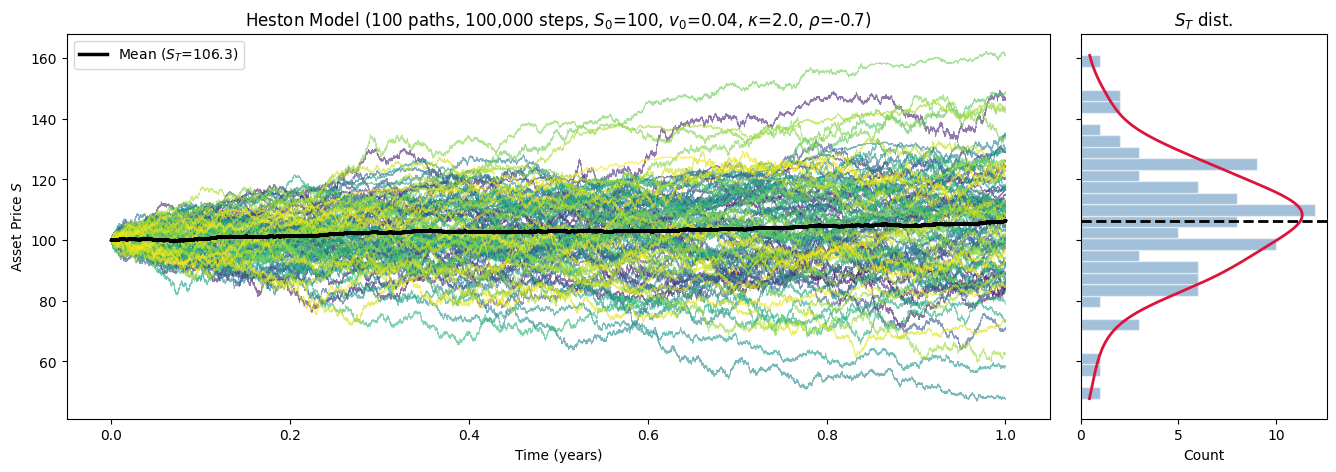

In [37]:
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)
ax_paths = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharey=ax_paths)
t = np.linspace(0, T, steps + 1)
colors = plt.cm.viridis(np.linspace(0, 1, num_paths))
for i in range(num_paths):
    ax_paths.plot(t, paths[:, i], lw=0.5, alpha=0.6, color=colors[i])
mean_path = np.mean(paths, axis=1)
ax_paths.plot(t, mean_path, lw=2.5, color='black', label=f'Mean ($S_T$={mean_path[-1]:.1f})')
ax_paths.set_title(f'Heston Model ({num_paths} paths, {steps:,} steps, $S_0$={S0}, $v_0$={v0}, $\\kappa$={kappa}, $\\rho$={rho})')
ax_paths.set_xlabel('Time (years)')
ax_paths.set_ylabel('Asset Price $S$')
ax_paths.legend(loc='upper left')
terminal = paths[-1, :]
ax_hist.hist(terminal, bins=30, orientation='horizontal', color='steelblue', alpha=0.5, edgecolor='white')
kde = gaussian_kde(terminal)
y_range = np.linspace(terminal.min(), terminal.max(), 200)
kde_vals = kde(y_range)
kde_scaled = kde_vals / kde_vals.max() * ax_hist.get_xlim()[1] * 0.9
ax_hist.plot(kde_scaled, y_range, color='crimson', lw=2)
ax_hist.axhline(np.mean(terminal), color='black', lw=2, linestyle='--')
ax_hist.set_xlabel('Count')
ax_hist.tick_params(labelleft=False)
ax_hist.set_title('$S_T$ dist.')
fig.subplots_adjust(left=0.07, right=0.97, top=0.90, bottom=0.13)
plt.savefig(out_path, bbox_inches="tight")
plt.show()

#### Variance 

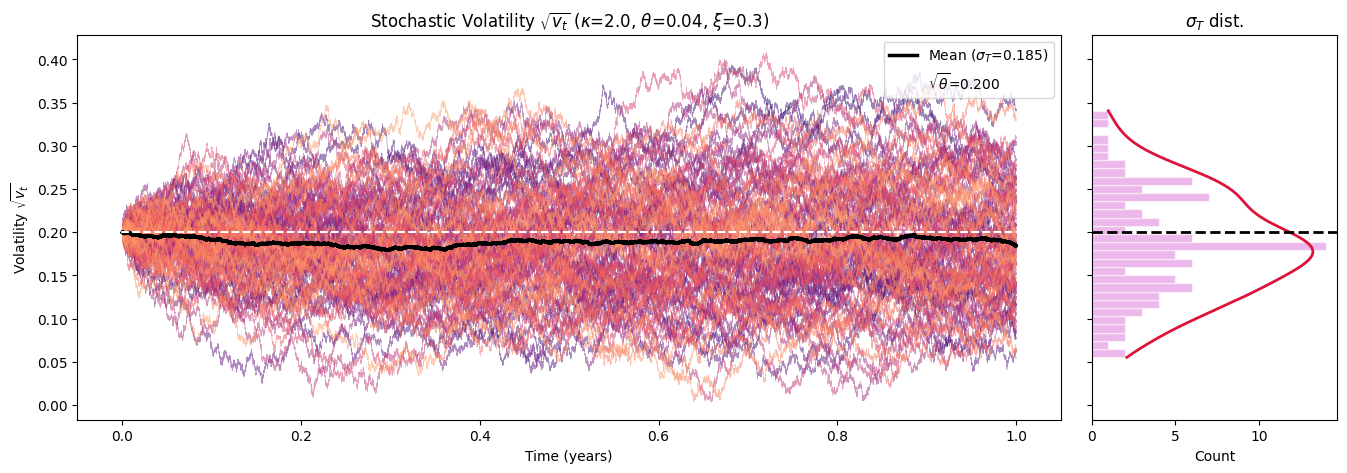

In [38]:
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)
ax_vol = fig.add_subplot(gs[0])
ax_hist_v = fig.add_subplot(gs[1], sharey=ax_vol)

t = np.linspace(0, T, steps + 1)
colors_v = plt.cm.magma(np.linspace(0.2, 0.8, num_paths))
for i in range(num_paths):
    ax_vol.plot(t, np.sqrt(vols[:, i]), lw=0.4, alpha=0.5, color=colors_v[i])

mean_vol = np.mean(np.sqrt(vols), axis=1)
ax_vol.plot(t, mean_vol, lw=2.5, color='black', label=f'Mean ($\\sigma_T$={mean_vol[-1]:.3f})')
ax_vol.axhline(np.sqrt(theta), color='white', lw=1.5, ls='--', label=f'$\\sqrt{{\\theta}}$={np.sqrt(theta):.3f}')

ax_vol.set_title(f'Stochastic Volatility $\\sqrt{{v_t}}$ ($\\kappa$={kappa}, $\\theta$={theta}, $\\xi$={xi})')
ax_vol.set_xlabel('Time (years)')
ax_vol.set_ylabel('Volatility $\\sqrt{v_t}$')
ax_vol.legend(loc='upper right')

terminal_vol = np.sqrt(vols[-1, :])
ax_hist_v.hist(terminal_vol, bins=30, orientation='horizontal', color='orchid', alpha=0.5, edgecolor='white')
kde_v = gaussian_kde(terminal_vol)
y_range_v = np.linspace(terminal_vol.min(), terminal_vol.max(), 200)
kde_vals_v = kde_v(y_range_v)
kde_scaled_v = kde_vals_v / kde_vals_v.max() * ax_hist_v.get_xlim()[1] * 0.9
ax_hist_v.plot(kde_scaled_v, y_range_v, color='crimson', lw=2)
ax_hist_v.axhline(np.sqrt(theta), color='black', lw=2, ls='--')
ax_hist_v.tick_params(labelleft=False)
ax_hist_v.set_xlabel('Count')
ax_hist_v.set_title('$\\sigma_T$ dist.')

fig.subplots_adjust(left=0.07, right=0.97, top=0.90, bottom=0.13)
plt.savefig(out_dir / "heston_vol.pdf", bbox_inches="tight")
plt.show()

#### Log-return and normal distribution

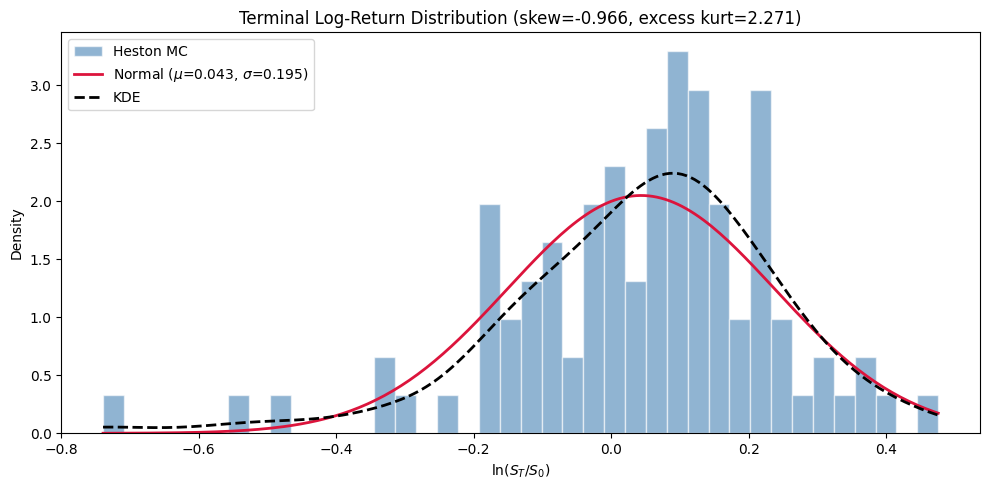

In [39]:
log_returns = np.log(paths[-1, :] / S0)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(log_returns, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='white', label='Heston MC')

mu_lr = np.mean(log_returns)
sigma_lr = np.std(log_returns)
x = np.linspace(log_returns.min(), log_returns.max(), 200)
ax.plot(x, norm.pdf(x, mu_lr, sigma_lr), lw=2, color='crimson', label=f'Normal ($\\mu$={mu_lr:.3f}, $\\sigma$={sigma_lr:.3f})')

kde_lr = gaussian_kde(log_returns)
ax.plot(x, kde_lr(x), lw=2, color='black', ls='--', label='KDE')

skew = np.mean(((log_returns - mu_lr) / sigma_lr) ** 3)
kurt = np.mean(((log_returns - mu_lr) / sigma_lr) ** 4) - 3
ax.set_title(f'Terminal Log-Return Distribution (skew={skew:.3f}, excess kurt={kurt:.3f})')
ax.set_xlabel('$\\ln(S_T / S_0)$')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig(out_dir / "heston_returns.pdf", bbox_inches="tight")
plt.show()

### Save plots to Google Drive

In [40]:
if IN_COLAB:
    from google.colab import drive
    import shutil

    drive.mount('/content/drive')

    drive_dest = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda/")
    drive_dest.mkdir(parents=True, exist_ok=True)

    for name in ["heston.pdf", "heston_vol.pdf", "heston_returns.pdf"]:
        src = out_dir / name
        if src.exists():
            shutil.copy2(src, drive_dest / name)
            print(f"Copied: {name} -> {drive_dest / name}")
        else:
            print(f"Not found: {src}")
else:
    print(f"PDFs saved locally to: {out_dir.resolve()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied: heston.pdf -> /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda/heston.pdf
Copied: heston_vol.pdf -> /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda/heston_vol.pdf
Copied: heston_returns.pdf -> /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda/heston_returns.pdf
